In [1]:
import polars as pl
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

polars.config.Config

In [ ]:
CURRENT_DIR = Path().resolve()
BASE_DIR = CURRENT_DIR.parent.parent
DATA_FILE = BASE_DIR / "data" / "processed" / "options_surfaces_data_cleaned.parquet"
TARGET_FILE = BASE_DIR / "data" / "processed" / "returns.csv"

q = pl.read_parquet(DATA_FILE)

In [6]:
returns_df = (
    q.select(["underlying_symbol", "quote_datetime", "underlying_mid_price"])
    .unique()
    .sort(["underlying_symbol", "quote_datetime"])
)

returns_df = returns_df.with_columns([
    pl.col("underlying_mid_price")
    .log()
    .diff()
    .over("underlying_symbol")
    .alias("log_return")
])

wide_returns = returns_df.drop_nulls().pivot(
    values="log_return",
    index="quote_datetime",
    on="underlying_symbol"
)

wide_returns = wide_returns.fill_null(0.0)

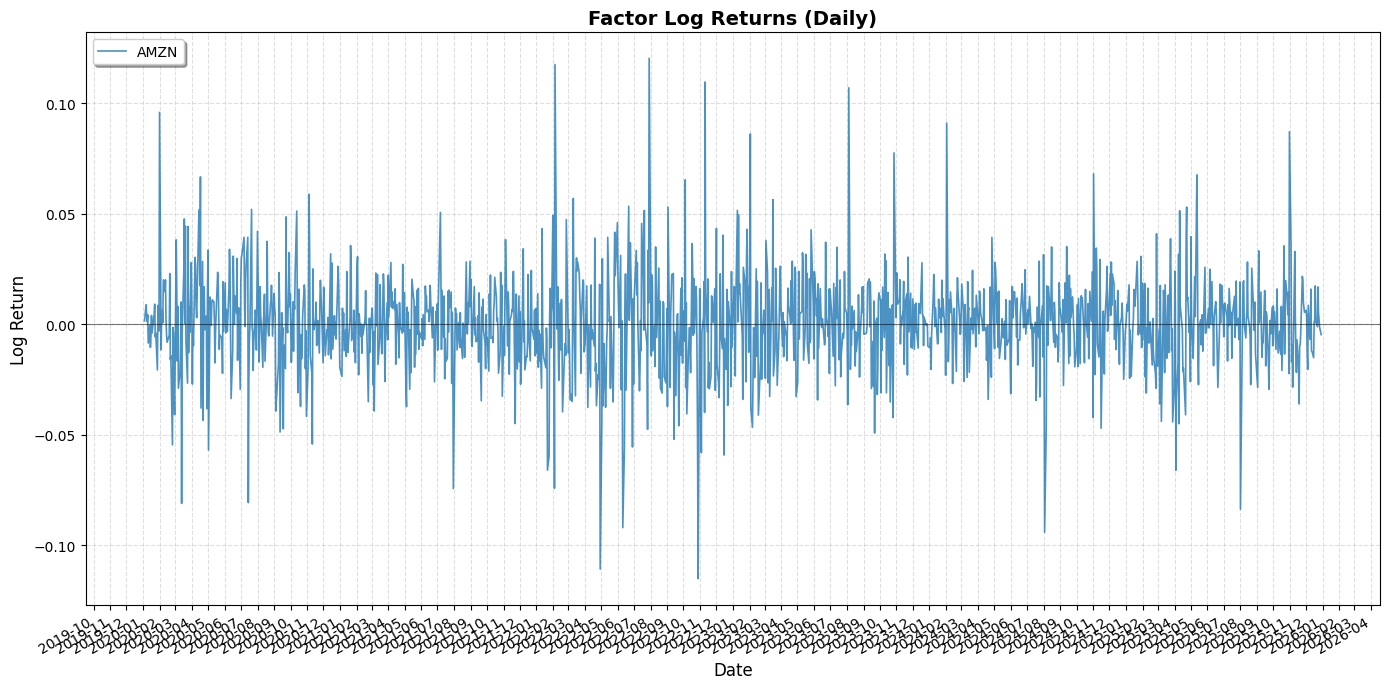

In [7]:
targets = ['AMZN']
plot_cols = [c for c in targets if c in wide_returns.columns]

plt.figure(figsize=(14, 7))

for col in plot_cols:
    plt.plot(
        wide_returns["quote_datetime"], 
        wide_returns[col], 
        label=col, 
        alpha=0.8, 
        linewidth=1.2
    )

plt.title("Factor Log Returns (Daily)", fontsize=14, fontweight='bold')
plt.ylabel("Log Return", fontsize=12)
plt.xlabel("Date", fontsize=12)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate() # Rotate dates

plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout()

In [ ]:
returns = wide_returns.to_pandas()
returns.to_csv(TARGET_FILE, index=False)